# Chapter 17 — Beyond One Variable

How a third variable can reverse a conclusion, and what a coefficient means with two predictors.

| Section | What it covers |
|---|---|
| 17.1 | Simpson’s paradox |
| 17.2 | Two predictors |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Beyond One Variable](https://khh-aka-lucifer.github.io/statLab/chapters/beyond-one-variable/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## The most dangerous chapter

Everything so far compared one thing against another. Real questions almost never come with only two
variables, and the third one can reverse your answer completely.

## 17.1 Simpson's paradox

In 1973 the University of California, Berkeley admitted 44 % of male applicants to graduate study
and 30 % of female applicants. Those are the real numbers, published in *Science* in 1975, and they
look like an open-and-shut case.

In [2]:
berkeley = pd.read_csv(DATA / "berkeley-admissions.csv")
berkeley["applied"] = berkeley["admitted"] + berkeley["rejected"]

overall = berkeley.groupby("gender")[["admitted", "applied"]].sum()
overall["rate"] = overall["admitted"] / overall["applied"]
overall

,admitted,applied,rate
gender,,,
Female,557,1835,0.303542
Male,1198,2691,0.445188


In [3]:
table = berkeley.groupby("gender")[["admitted", "rejected"]].sum()
chi2, p, dof, _ = stats.chi2_contingency(table, correction=False)

print(f"chi-square test on the pooled table: chi2 = {chi2:.1f}, p = {p:.3e}")
print("Overwhelmingly significant. Now look department by department.")

chi-square test on the pooled table: chi2 = 92.2, p = 7.814e-22
Overwhelmingly significant. Now look department by department.


In [4]:
by_dept = berkeley.pivot_table(index="department", columns="gender",
                               values=["admitted", "applied"], aggfunc="sum")
rates = pd.DataFrame({
    "men applied":   by_dept[("applied", "Male")],
    "men admitted %": (by_dept[("admitted", "Male")] / by_dept[("applied", "Male")] * 100).round(1),
    "women applied": by_dept[("applied", "Female")],
    "women admitted %": (by_dept[("admitted", "Female")] / by_dept[("applied", "Female")] * 100).round(1),
})
rates["women better?"] = np.where(rates["women admitted %"] > rates["men admitted %"], "yes", "no")
rates

,men applied,men admitted %,women applied,women admitted %,women better?
department,,,,,
A,825,62.1,108,82.4,yes
B,560,63.0,25,68.0,yes
C,325,36.9,593,34.1,no
D,417,33.1,375,34.9,yes
E,191,27.7,393,23.9,no
F,373,5.9,341,7.0,yes


In four of the six departments women were admitted at a *higher* rate than men. In the two where
they were not, the gap is small. Yet pooled together, men come out 14 points ahead.

Both facts are correct arithmetic on the same table. That is **Simpson's paradox**.

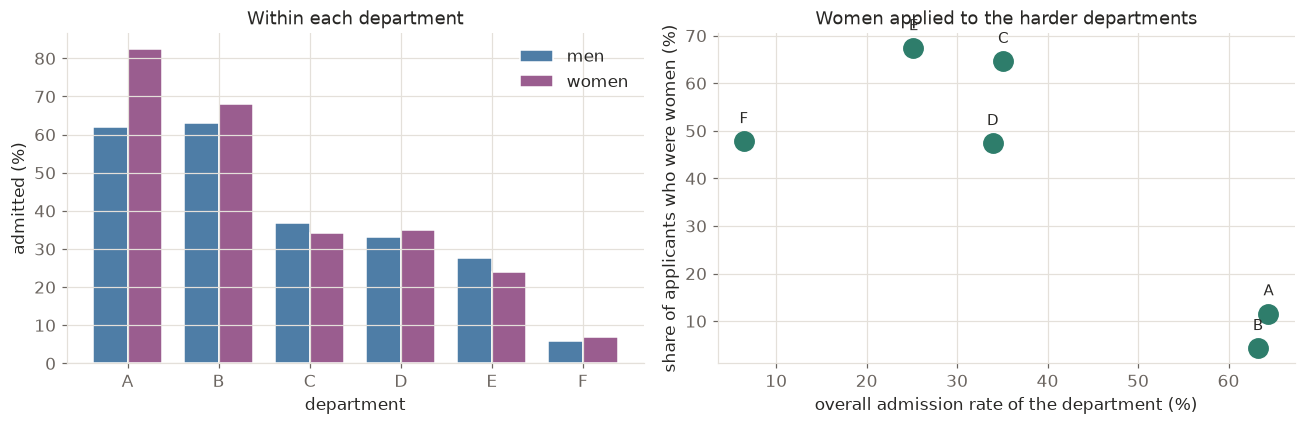

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))

depts = rates.index
width = 0.38
left.bar(np.arange(len(depts)) - width/2, rates["men admitted %"], width,
         color=C["cat3"], label="men", edgecolor="white")
left.bar(np.arange(len(depts)) + width/2, rates["women admitted %"], width,
         color=C["cat4"], label="women", edgecolor="white")
left.set_xticks(range(len(depts))); left.set_xticklabels(depts)
left.set_ylabel("admitted (%)"); left.set_xlabel("department")
left.set_title("Within each department"); left.legend()

# the explanation: where each gender applied, against how hard each department was
difficulty = (by_dept[("admitted", "Male")] + by_dept[("admitted", "Female")]) / \
             (by_dept[("applied", "Male")] + by_dept[("applied", "Female")]) * 100
share_female = by_dept[("applied", "Female")] / \
               (by_dept[("applied", "Male")] + by_dept[("applied", "Female")]) * 100

right.scatter(difficulty, share_female, s=160, color=C["accent"], zorder=3)
for d, x, y in zip(depts, difficulty, share_female):
    right.annotate(d, (x, y), textcoords="offset points", xytext=(0, 12),
                   ha="center", fontsize=10, color=C["ink"])
right.set_xlabel("overall admission rate of the department (%)")
right.set_ylabel("share of applicants who were women (%)")
right.set_title("Women applied to the harder departments")

plt.tight_layout()
plt.show()

The right panel is the resolution. Departments A and B admitted more than half of all applicants and
were overwhelmingly applied to by men. Departments C, E and F admitted under a third, and women made
up most of their applicants.

Women were not rejected at higher rates. They applied, in much larger numbers, to the departments
that rejected almost everybody.

The lurking variable is **which department you apply to**, and it is correlated with both gender and
admission. Conditioning on it flips the conclusion. The original paper's point was exactly this, and
it is why the study is still taught fifty years later.

In [6]:
# the same thing in one number: pooled versus weighted by department
pooled_gap = overall.loc["Male", "rate"] - overall.loc["Female", "rate"]

weights = (by_dept[("applied", "Male")] + by_dept[("applied", "Female")])
within_gaps = (by_dept[("admitted", "Male")] / by_dept[("applied", "Male")] -
               by_dept[("admitted", "Female")] / by_dept[("applied", "Female")])
adjusted_gap = np.average(within_gaps, weights=weights)

print(f"pooled gap (men minus women):            {pooled_gap:+.4f}")
print(f"gap after adjusting for department:      {adjusted_gap:+.4f}")
print("\nThe sign flips. Same data, one extra column.")

pooled gap (men minus women):            +0.1416
gap after adjusting for department:      -0.0426

The sign flips. Same data, one extra column.


In [ ]:
# Your turn.
# The gapminder data hides the same trap.
# Fit life expectancy against log10(gdpPercap) for ALL countries in 2007, then separately
# within each continent.
# 1. Is the pooled slope steeper or shallower than the typical within-continent slope?
# 2. What does that tell you about comparing countries across continents?

gap = pd.read_csv(DATA / "gapminder.csv")
...

## 17.2 Two predictors

The fix for a lurking variable is to put it in the model. With two predictors,

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2$$

and the meaning of $b_1$ changes. It is no longer "the effect of $x_1$". It is the effect of $x_1$
**holding $x_2$ fixed**, which is a different and much narrower claim.

Cars make this concrete. Heavy cars use more fuel, and powerful cars use more fuel, and heavy cars
tend to be powerful.

In [7]:
cars = pd.read_csv(DATA / "cars.csv").dropna(subset=["mpg", "weight", "horsepower"])

print(f"{len(cars)} cars")
print(f"correlation between weight and horsepower: "
      f"{np.corrcoef(cars['weight'], cars['horsepower'])[0,1]:.4f}   <- they travel together")

392 cars
correlation between weight and horsepower: 0.8645   <- they travel together


In [8]:
# one predictor at a time
solo_weight = stats.linregress(cars["weight"], cars["mpg"])
solo_power  = stats.linregress(cars["horsepower"], cars["mpg"])

print(f"mpg on weight alone:     slope {solo_weight.slope:.5f} mpg per lb   (r2 = {solo_weight.rvalue**2:.3f})")
print(f"mpg on horsepower alone: slope {solo_power.slope:.5f} mpg per hp   (r2 = {solo_power.rvalue**2:.3f})")

mpg on weight alone:     slope -0.00765 mpg per lb   (r2 = 0.693)
mpg on horsepower alone: slope -0.15784 mpg per hp   (r2 = 0.606)


In [9]:
# both together, by least squares on a design matrix
X = np.column_stack([np.ones(len(cars)), cars["weight"], cars["horsepower"]])
y = cars["mpg"].to_numpy()

coeffs, residuals_ss, *_ = np.linalg.lstsq(X, y, rcond=None)
b0, b_weight, b_power = coeffs

r2 = 1 - ((y - X @ coeffs)**2).sum() / ((y - y.mean())**2).sum()

print(f"intercept   {b0:10.4f}")
print(f"weight      {b_weight:10.5f} mpg per lb, holding horsepower fixed")
print(f"horsepower  {b_power:10.5f} mpg per hp, holding weight fixed")
print(f"r2          {r2:10.4f}")

intercept      45.6402
weight        -0.00579 mpg per lb, holding horsepower fixed
horsepower    -0.04730 mpg per hp, holding weight fixed
r2              0.7064


Look at what happened to horsepower. On its own it was worth $-0.158$ mpg per unit. With weight in
the model it drops to $-0.047$, about a third of the size.

Most of what "horsepower" appeared to explain was really weight wearing a disguise. Powerful cars are
heavy, heavy cars use fuel, and a model with only horsepower credits it with the whole effect.

In [10]:
comparison = pd.DataFrame({
    "alone":        [solo_weight.slope, solo_power.slope],
    "with the other": [b_weight, b_power],
}, index=["weight (per lb)", "horsepower (per hp)"])
comparison["shrunk to"] = (comparison["with the other"] / comparison["alone"]).map("{:.0%}".format)
comparison.round(5)

,alone,with the other,shrunk to
weight (per lb),-0.00765,-0.00579,76%
horsepower (per hp),-0.15784,-0.04730,30%


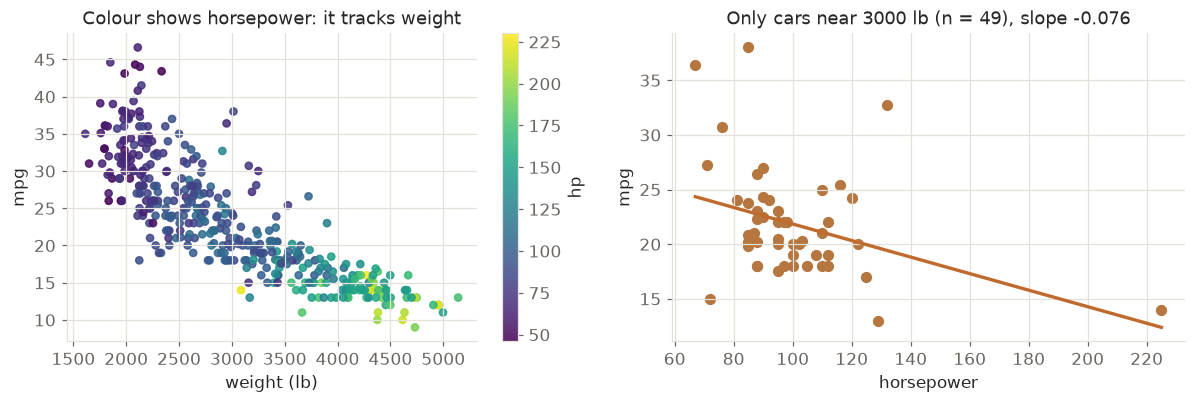

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

scatter = left.scatter(cars["weight"], cars["mpg"], c=cars["horsepower"],
                       cmap="viridis", s=22, alpha=0.85)
left.set_xlabel("weight (lb)"); left.set_ylabel("mpg")
left.set_title("Colour shows horsepower: it tracks weight")
fig.colorbar(scatter, ax=left, label="hp")

# holding weight fixed, in pictures: look within a narrow weight band
band = cars[(cars["weight"] > 2800) & (cars["weight"] < 3200)]
right.scatter(band["horsepower"], band["mpg"], s=40, color=C["cat2"])
fit = stats.linregress(band["horsepower"], band["mpg"])
hp_grid = np.linspace(band["horsepower"].min(), band["horsepower"].max(), 50)
right.plot(hp_grid, fit.intercept + fit.slope*hp_grid, color=C["warn"], lw=2.2)
right.set_xlabel("horsepower"); right.set_ylabel("mpg")
right.set_title(f"Only cars near 3000 lb (n = {len(band)}), slope {fit.slope:.3f}")

plt.tight_layout()
plt.show()

The right panel is "holding weight fixed" done by hand. Look only at cars of roughly one weight, and
the horsepower slope falls to something close to the multiple-regression coefficient. That is what
the coefficient means, and it is worth doing once by hand so the phrase stops being a formula.

### The warning that goes with all of this

Adding a variable changes what the others mean. Which variables you include is a modelling choice,
and different honest choices give different coefficients from the same data.

No amount of regression turns this into causation. Berkeley's departments explained the admission
gap arithmetically, and they did not establish that nothing unfair happened. They relocated the
question, from "are women rejected more" to "why did women apply to the underfunded departments",
which the data cannot answer at all.

In [ ]:
# Your turn.
# Add a third predictor to the cars model: model_year.
# 1. Fit mpg on weight, horsepower and model_year together.
# 2. What happens to the weight and horsepower coefficients?
# 3. What does the model_year coefficient mean in plain words?

...

## Exercises

1. **Build a paradox.** Construct a small fake data set from scratch where a treatment looks better
   overall but worse in both subgroups. Getting the group sizes right is the whole trick.

2. **Berkeley by department, tested.** Run a chi-square test of independence separately for each
   department. How many are significant, and in which direction?

3. **The Titanic version.** Compare survival by embarkation port, then again within each class.
   Chapter 11 hinted at this. Does the port effect survive?

4. **Collinearity.** Fit mpg on weight and on weight-in-kilograms at the same time. The two
   predictors carry identical information, and the fit will behave badly. Look at what `lstsq`
   returns and explain why the coefficients are meaningless.

5. **Adding noise helps r squared.** Add a column of pure random numbers to the cars model and refit.
   $r^2$ will go up, because it always does. Look up adjusted $r^2$ and see how it responds.

## What you should take away

A third variable can reverse the sign of a relationship, and Berkeley is the real case that proves
it. Whenever you compare two groups, ask what else differs between them.

With more than one predictor, a coefficient means "holding the others fixed", which is a narrower
claim than it sounds and depends entirely on what else is in the model. Horsepower lost two thirds of
its apparent effect once weight was there to take the credit.

And none of it is causation. Statistics can tell you that a comparison is confounded and can adjust
for what you measured. It cannot tell you about the variable you never wrote down.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*